# CT Preprocessing Pipeline

**Input:** 281 raw NIfTI CT volumes + masks (MSD Task07 Pancreas), `data/raw/Task07_Pancreas/`
**Output:** a training-ready 2D axial slice dataset, `data/processed/`

Turns the raw 3D volumes into independent 2D slices: integrity-checked, reoriented to canonical RAS, resampled to 1x1x1mm isotropic spacing, HU-windowed, normalised, split by patient (not slice) stratified by lesion size, and saved as uint8 `.npy` arrays with a CSV manifest.

Every design decision below traces back to an EDA finding in `notebooks/CT EDA.ipynb` / `docs/CT_EDA_documentation.md` or an explicit hardware constraint (4GB GPU, 50GB disk) — none of the parameters here are arbitrary defaults.

In [1]:
import os
import json
import random
import shutil
import time
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully")

All libraries imported successfully


## Configuration

Every tunable parameter lives here, not scattered inline — spacing, HU window, risk-score floor, split ratios, and output location.

In [2]:
# --- Paths ---
DATA_DIR   = r"C:\FYP\data\raw\Task07_Pancreas\\"
IMG_DIR    = DATA_DIR + "imagesTr\\"
MASK_DIR   = DATA_DIR + "labelsTr\\"
OUTPUT_DIR = r"C:\FYP\data\processed"
QA_OUTPUT_DIR = r"C:\FYP\outputs\qa\ct"   # QA figures live outside data/processed -- not a pipeline input

# --- Resampling (Section 3/4 of the EDA: spacing varies 0.6-0.98mm in-plane,
#     0.7-7.5mm in Z -- isotropic 1mm is the EDA-derived target) ---
TARGET_SPACING = (1.0, 1.0, 1.0)   # mm, isotropic
IMAGE_INTERPOLATOR = sitk.sitkLinear        # continuous HU intensities
MASK_INTERPOLATOR  = sitk.sitkNearestNeighbor  # discrete labels -- never linear

# --- HU windowing (EDA Section 5: pancreas 25-55 HU, tumour 10-40 HU) ---
HU_MIN, HU_MAX = -150, 250

# --- Slice-level risk score (organ-relative, NOT total-pixel-fraction --
#     that formula was rejected as barely learnable) ---
RISK_SCORE_DENOM_FLOOR = 50   # pancreas_px + tumour_px must reach this or risk_score = 0

# --- Patient-level split, stratified by lesion-size quartile ---
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
N_LESION_STRATA = 4   # quartiles
RANDOM_SEED = 42

# --- Visual QA ---
N_QA_SAMPLES = 5

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9, "split fractions must sum to 1"

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Target spacing: {TARGET_SPACING} mm")
print(f"HU window: [{HU_MIN}, {HU_MAX}]")
print(f"Output dir: {OUTPUT_DIR}")
print(f"QA output dir: {QA_OUTPUT_DIR}")

Target spacing: (1.0, 1.0, 1.0) mm
HU window: [-150, 250]
Output dir: C:\FYP\data\processed


## Reused EDA Helper Functions

Identical implementations from `notebooks/CT EDA.ipynb`'s Helper Functions section. Copied rather than imported — notebook-to-notebook imports aren't practical without adding a new dependency (`importnb`/`ipynb`) for five short functions, and this project's workflow is notebook-only (no shared `.py` modules in `src/`). Any future change to loading behaviour needs updating in both places — flagged here deliberately rather than silently duplicated.

In [3]:
class CTLoadError(Exception):
    """Raised when a CT or mask NIfTI file fails to load.

    Carries the filename so callers can report *which* patient failed
    instead of the whole loop crashing.
    """

    def __init__(self, fname: str, original: Exception):
        super().__init__(f"Failed to load {fname}: {original}")
        self.fname = fname
        self.original = original


def load_ct(fname: str, img_dir: str) -> tuple[np.ndarray, nib.Nifti1Image]:
    """Load one CT volume. Returns (array, nib image)."""
    try:
        ct_nib = nib.load(img_dir + fname)
        return ct_nib.get_fdata(), ct_nib
    except Exception as e:
        raise CTLoadError(fname, e) from e


def load_mask(fname: str, mask_dir: str) -> tuple[np.ndarray, nib.Nifti1Image]:
    """Load one segmentation mask. Returns (array, nib image)."""
    try:
        mask_nib = nib.load(mask_dir + fname)
        return mask_nib.get_fdata(), mask_nib
    except Exception as e:
        raise CTLoadError(fname, e) from e


def load_ct_mask_pair(
    fname: str, img_dir: str, mask_dir: str
) -> tuple[np.ndarray, np.ndarray, nib.Nifti1Image, nib.Nifti1Image]:
    """Load a matched CT + mask pair in one call."""
    ct, ct_nib = load_ct(fname, img_dir)
    mask, mask_nib = load_mask(fname, mask_dir)
    return ct, mask, ct_nib, mask_nib


def patient_id_from_filename(fname: str) -> str:
    """Strip the .nii.gz extension, e.g. 'pancreas_001.nii.gz' -> 'pancreas_001'."""
    return fname.replace('.nii.gz', '')


def mask_region_values(ct: np.ndarray, mask: np.ndarray, label: int) -> np.ndarray:
    """CT voxel values inside one mask label (0=background, 1=pancreas, 2=tumour)."""
    return ct[mask == label]


print("EDA helpers reused: load_ct, load_mask, load_ct_mask_pair, "
      "patient_id_from_filename, mask_region_values, CTLoadError")

EDA helpers reused: load_ct, load_mask, load_ct_mask_pair, patient_id_from_filename, mask_region_values, CTLoadError


## Pipeline Step Functions

One small, docstringed function per pipeline step, in the order they're applied.

In [4]:
def reorient_to_ras(image: sitk.Image) -> sitk.Image:
    """Reorient a SimpleITK image to canonical RAS anatomical orientation.

    The EDA integrity pass found 0 orientation outliers in this dataset
    already (majority orientation was RAS) -- so for nearly every patient
    here this is a defensive no-op. It guards against a differently-sourced
    copy of this data in the future where that might not hold.
    """
    return sitk.DICOMOrient(image, 'RAS')


def resample_to_spacing(
    image: sitk.Image,
    target_spacing: tuple[float, float, float],
    interpolator: int,
    default_value: float = 0.0,
) -> sitk.Image:
    """Resample a SimpleITK image to isotropic target spacing.

    Physical extent is preserved; the pixel grid changes to match the new
    spacing. `interpolator` must match the content type at the call site --
    linear for continuous HU intensities, nearest-neighbour for discrete
    mask labels. Using the same interpolator for both is a correctness bug,
    not a style choice (linear interpolation invents fractional label
    values that don't exist, e.g. 1.4 between pancreas=1 and tumour=2).
    """
    original_spacing = image.GetSpacing()
    original_size = image.GetSize()
    new_size = [
        int(round(osz * ospc / tspc))
        for osz, ospc, tspc in zip(original_size, original_spacing, target_spacing)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(target_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(image.GetDirection())
    resampler.SetOutputOrigin(image.GetOrigin())
    resampler.SetTransform(sitk.Transform())
    resampler.SetDefaultPixelValue(default_value)
    resampler.SetInterpolator(interpolator)
    return resampler.Execute(image)


def clip_hu(array: np.ndarray, hu_min: float, hu_max: float) -> np.ndarray:
    """Clip HU intensities to the clinically-motivated window (EDA Section 5)."""
    return np.clip(array, hu_min, hu_max)


def normalize_to_unit_range(array: np.ndarray, hu_min: float, hu_max: float) -> np.ndarray:
    """Linearly rescale a HU-windowed array to [0, 1]."""
    return (array - hu_min) / (hu_max - hu_min)


def extract_axial_slices(volume_zyx: np.ndarray) -> list[np.ndarray]:
    """Split a SimpleITK-derived (z, y, x) array into a list of 2D axial slices.

    IMPORTANT: SimpleITK's GetArrayFromImage() returns (z, y, x) order --
    the OPPOSITE of nibabel's (x, y, z) used throughout the EDA notebook.
    Slicing here is along axis 0, not axis 2 as in the EDA code. Getting
    this backwards wouldn't crash, it would silently slice the wrong
    anatomical plane.
    """
    return [volume_zyx[i] for i in range(volume_zyx.shape[0])]


def compute_slice_risk_score(mask_slice: np.ndarray, denom_floor: int) -> float:
    """Per-slice risk score = tumour_px / (pancreas_px + tumour_px).

    Organ-relative denominator, NOT total slice pixels -- the total-pixel
    formula was rejected as barely learnable (background-dominated, near-
    zero on almost every slice). Floored to 0 when the organ isn't visible
    enough in this slice to make the ratio meaningful (denom < denom_floor).
    """
    tumour_px = int(np.sum(mask_slice == 2))
    pancreas_px = int(np.sum(mask_slice == 1))
    denom = pancreas_px + tumour_px
    if denom < denom_floor:
        return 0.0
    return tumour_px / denom


def slice_to_uint8_image(slice_2d: np.ndarray) -> np.ndarray:
    """Convert a [0, 1]-normalised HU-windowed slice to uint8 (0-255).

    uint8 instead of float32 cuts per-slice storage 4x -- roughly the
    difference between this pipeline's ~25GB output and ~100GB, against a
    50GB budget.
    """
    return np.clip(slice_2d * 255.0, 0, 255).round().astype(np.uint8)


def mask_to_uint8(mask_slice: np.ndarray) -> np.ndarray:
    """Store the mask as uint8 with its original label values (0/1/2) intact.

    NOT scaled to [0, 255] like the image -- these are categorical labels,
    not a continuous quantity. Scaling them would need an error-prone
    inverse step to recover the original labels during training, for no
    benefit; uint8 already holds 0-2 losslessly.
    """
    return mask_slice.astype(np.uint8)


def stratified_patient_split(
    patient_ids: list[str],
    lesion_volumes_mm3: list[float],
    train_frac: float,
    val_frac: float,
    test_frac: float,
    n_strata: int,
    seed: int,
) -> dict[str, list[str]]:
    """Split patient IDs into train/val/test, stratified by lesion-size
    quartile so each split gets a representative spread of small/large
    lesions. Splits PATIENTS, not slices -- splitting slices would leak the
    same patient's anatomy across train and test.
    """
    strata = pd.qcut(lesion_volumes_mm3, q=n_strata, labels=False, duplicates='drop')

    train_ids, rest_ids, _, rest_strata = train_test_split(
        patient_ids, strata, train_size=train_frac, stratify=strata, random_state=seed
    )
    val_ratio_of_rest = val_frac / (val_frac + test_frac)
    val_ids, test_ids = train_test_split(
        rest_ids, train_size=val_ratio_of_rest, stratify=rest_strata, random_state=seed
    )
    return {'train': list(train_ids), 'val': list(val_ids), 'test': list(test_ids)}


print("Pipeline step functions defined.")

Pipeline step functions defined.


## Step 1: Integrity Gate + Lesion Volume

Reuses `load_ct_mask_pair`/`CTLoadError` exactly as the EDA notebook does. Excludes (rather than crashes on) any patient that fails to load, has a shape mismatch, or has mask labels outside `{0, 1, 2}` -- logged by patient ID. The EDA already found 0 such patients, so this is a defensive re-check, not expected to exclude anyone.

Folded into the same pass: each valid patient's tumour volume in mm³ is computed here too (reusing the exact EDA Section 2b formula) since it's needed later for the lesion-size-stratified split -- no reason to reload all 281 volumes a second time just for that.

In [5]:
img_files = sorted([
    f for f in os.listdir(IMG_DIR)
    if f.endswith('.nii.gz') and not f.startswith('._')
])

print(f"Running integrity gate on {len(img_files)} candidate patients...")

excluded = []          # (patient_id, reason)
valid_patients = []     # patient_ids that passed
lesion_volume_mm3 = {}  # patient_id -> tumour volume in mm^3

for fname in img_files:
    pid = patient_id_from_filename(fname)
    try:
        ct, mask, ct_nib, mask_nib = load_ct_mask_pair(fname, IMG_DIR, MASK_DIR)
    except CTLoadError as e:
        excluded.append((pid, f"load_error: {e}"))
        continue

    if ct.shape != mask.shape:
        excluded.append((pid, f"shape_mismatch: ct={ct.shape} mask={mask.shape}"))
        continue

    unique_labels = set(np.unique(mask).astype(int).tolist())
    if not unique_labels.issubset({0, 1, 2}):
        excluded.append((pid, f"label_violation: found {sorted(unique_labels)}"))
        continue

    voxel_volume_mm3 = float(np.prod(mask_nib.header.get_zooms()))
    lesion_volume_mm3[pid] = int(np.sum(mask == 2)) * voxel_volume_mm3
    valid_patients.append(pid)

print("\n" + "=" * 55)
print("  INTEGRITY GATE RESULT")
print("=" * 55)
print(f"  Candidates checked: {len(img_files)}")
print(f"  Passed:             {len(valid_patients)}")
print(f"  Excluded:            {len(excluded)}")
for pid, reason in excluded:
    print(f"    - {pid}: {reason}")

Running integrity gate on 281 candidate patients...



  INTEGRITY GATE RESULT
  Candidates checked: 281
  Passed:             281
  Excluded:            0


## Step 9 (computed early): Patient Split

Split assignment is computed now, before the heavy per-slice processing loop, since every patient needs to know its split label while its slices are being saved into `images/{split}/` and `masks/{split}/`.

In [6]:
lesion_volumes_ordered = [lesion_volume_mm3[pid] for pid in valid_patients]

split_assignment = stratified_patient_split(
    valid_patients, lesion_volumes_ordered,
    TRAIN_FRAC, VAL_FRAC, TEST_FRAC, N_LESION_STRATA, RANDOM_SEED
)
patient_to_split = {
    pid: split
    for split, pids in split_assignment.items()
    for pid in pids
}

print("Patient split (stratified by lesion-size quartile):")
for split, pids in split_assignment.items():
    print(f"  {split}: {len(pids)} patients")

Patient split (stratified by lesion-size quartile):
  train: 196 patients
  val: 42 patients
  test: 43 patients


## Steps 2-8, 10: Main Processing Loop

For every patient that passed the integrity gate: reorient, resample, window, normalise, extract slices, compute risk scores, save as uint8 `.npy`. No rebalancing at storage time (Step 8) — this is an absence, not code: the loop below saves every slice it extracts, tumour or not, at the dataset's natural ~9.5% tumour rate.

The whole per-patient block is wrapped in try/except separately from the integrity gate above — that gate only checked the raw nibabel load; this catches failures in the SimpleITK reorient/resample stage itself, reported the same way (by patient ID, logged, loop continues).

In [7]:
for split in ['train', 'val', 'test']:
    Path(OUTPUT_DIR, 'images', split).mkdir(parents=True, exist_ok=True)
    Path(OUTPUT_DIR, 'masks', split).mkdir(parents=True, exist_ok=True)

manifest_rows = []
processing_failures = []  # (patient_id, error message) -- distinct from integrity-gate exclusions

start_time = time.time()
for n, pid in enumerate(valid_patients, 1):
    fname = pid + '.nii.gz'
    split = patient_to_split[pid]
    try:
        ct_img = sitk.ReadImage(IMG_DIR + fname)
        mask_img = sitk.ReadImage(MASK_DIR + fname)

        ct_img = reorient_to_ras(ct_img)
        mask_img = reorient_to_ras(mask_img)

        ct_img = resample_to_spacing(ct_img, TARGET_SPACING, IMAGE_INTERPOLATOR, default_value=-1024)
        mask_img = resample_to_spacing(mask_img, TARGET_SPACING, MASK_INTERPOLATOR, default_value=0)

        ct_arr = sitk.GetArrayFromImage(ct_img)      # (z, y, x)
        mask_arr = sitk.GetArrayFromImage(mask_img)  # (z, y, x)

        ct_arr = clip_hu(ct_arr, HU_MIN, HU_MAX)
        ct_arr = normalize_to_unit_range(ct_arr, HU_MIN, HU_MAX)

        ct_slices = extract_axial_slices(ct_arr)
        mask_slices = extract_axial_slices(mask_arr)

        for slice_idx, (ct_slice, mask_slice) in enumerate(zip(ct_slices, mask_slices)):
            risk_score = compute_slice_risk_score(mask_slice, RISK_SCORE_DENOM_FLOOR)

            img_u8 = slice_to_uint8_image(ct_slice)
            mask_u8 = mask_to_uint8(mask_slice)

            img_fname = f"{pid}_slice{slice_idx:04d}.npy"
            mask_fname = f"{pid}_slice{slice_idx:04d}.npy"
            img_path = os.path.join('images', split, img_fname)
            mask_path = os.path.join('masks', split, mask_fname)

            np.save(os.path.join(OUTPUT_DIR, img_path), img_u8)
            np.save(os.path.join(OUTPUT_DIR, mask_path), mask_u8)

            manifest_rows.append({
                'patient_id': pid,
                'slice_index': slice_idx,
                'split': split,
                'risk_score': risk_score,
                'image_path': img_path.replace(os.sep, '/'),
                'mask_path': mask_path.replace(os.sep, '/'),
            })

    except Exception as e:
        processing_failures.append((pid, str(e)))
        continue

    if n % 40 == 0 or n == len(valid_patients):
        elapsed = time.time() - start_time
        print(f"  Processed {n}/{len(valid_patients)} patients "
              f"({elapsed/60:.1f} min elapsed)")

print(f"\nProcessing complete. {len(processing_failures)} patients failed during "
      f"reorient/resample/save (separate from integrity-gate exclusions above).")
for pid, err in processing_failures:
    print(f"  - {pid}: {err}")

  Processed 40/281 patients (0.9 min elapsed)


  Processed 80/281 patients (2.0 min elapsed)


  Processed 120/281 patients (3.1 min elapsed)


  Processed 160/281 patients (4.3 min elapsed)


  Processed 200/281 patients (5.5 min elapsed)


  Processed 240/281 patients (6.8 min elapsed)


  Processed 280/281 patients (8.3 min elapsed)


  Processed 281/281 patients (8.3 min elapsed)

Processing complete. 0 patients failed during reorient/resample/save (separate from integrity-gate exclusions above).


## Save Manifest (Step 10)

Note on `slice_index`: this is the position within the **resampled** 1mm-isotropic volume that was actually extracted and saved — not the position in the raw, pre-resample NIfTI. Reconstructing a patient's full volume from these slices reconstructs the resampled space (the same space the model trains on), which is what matters here.

In [8]:
manifest_df = pd.DataFrame(manifest_rows)
manifest_path = os.path.join(OUTPUT_DIR, 'manifest.csv')
manifest_df.to_csv(manifest_path, index=False)

print(f"Manifest saved: {manifest_path}")
print(f"Total slices in manifest: {len(manifest_df):,}")
print(manifest_df['split'].value_counts())

Manifest saved: C:\FYP\data\processed\manifest.csv
Total slices in manifest: 72,077
split
train    50337
test     11154
val      10586
Name: count, dtype: int64


## Disk Usage Check

Confirms actual measured output size against the 50GB budget — not an estimate.

In [9]:
def get_dir_size_bytes(path: str) -> int:
    """Total size in bytes of every file under `path`, recursively."""
    total = 0
    for root, _, files in os.walk(path):
        for f in files:
            total += os.path.getsize(os.path.join(root, f))
    return total


output_size_bytes = get_dir_size_bytes(OUTPUT_DIR)
output_size_gb = output_size_bytes / 1e9
budget_gb = 50.0

print(f"Total output size: {output_size_gb:.2f} GB")
print(f"Budget:             {budget_gb:.0f} GB")
if output_size_gb <= budget_gb:
    print(f"WITHIN BUDGET -- {budget_gb - output_size_gb:.2f} GB to spare")
else:
    print(f"OVER BUDGET by {output_size_gb - budget_gb:.2f} GB")

free_space_gb = shutil.disk_usage(OUTPUT_DIR).free / 1e9
print(f"Actual free disk space remaining on this drive: {free_space_gb:.2f} GB")

Total output size: 25.35 GB
Budget:             50 GB
WITHIN BUDGET -- 24.65 GB to spare
Actual free disk space remaining on this drive: 323.87 GB


## Step 11: Post-Processing Visual QA

Loads the saved uint8 `.npy` files back from disk (round-trip check, not just re-plotting in-memory arrays) for a handful of random patients, and overlays image + mask to confirm alignment survived reorientation, resampling, and the uint8 conversion.

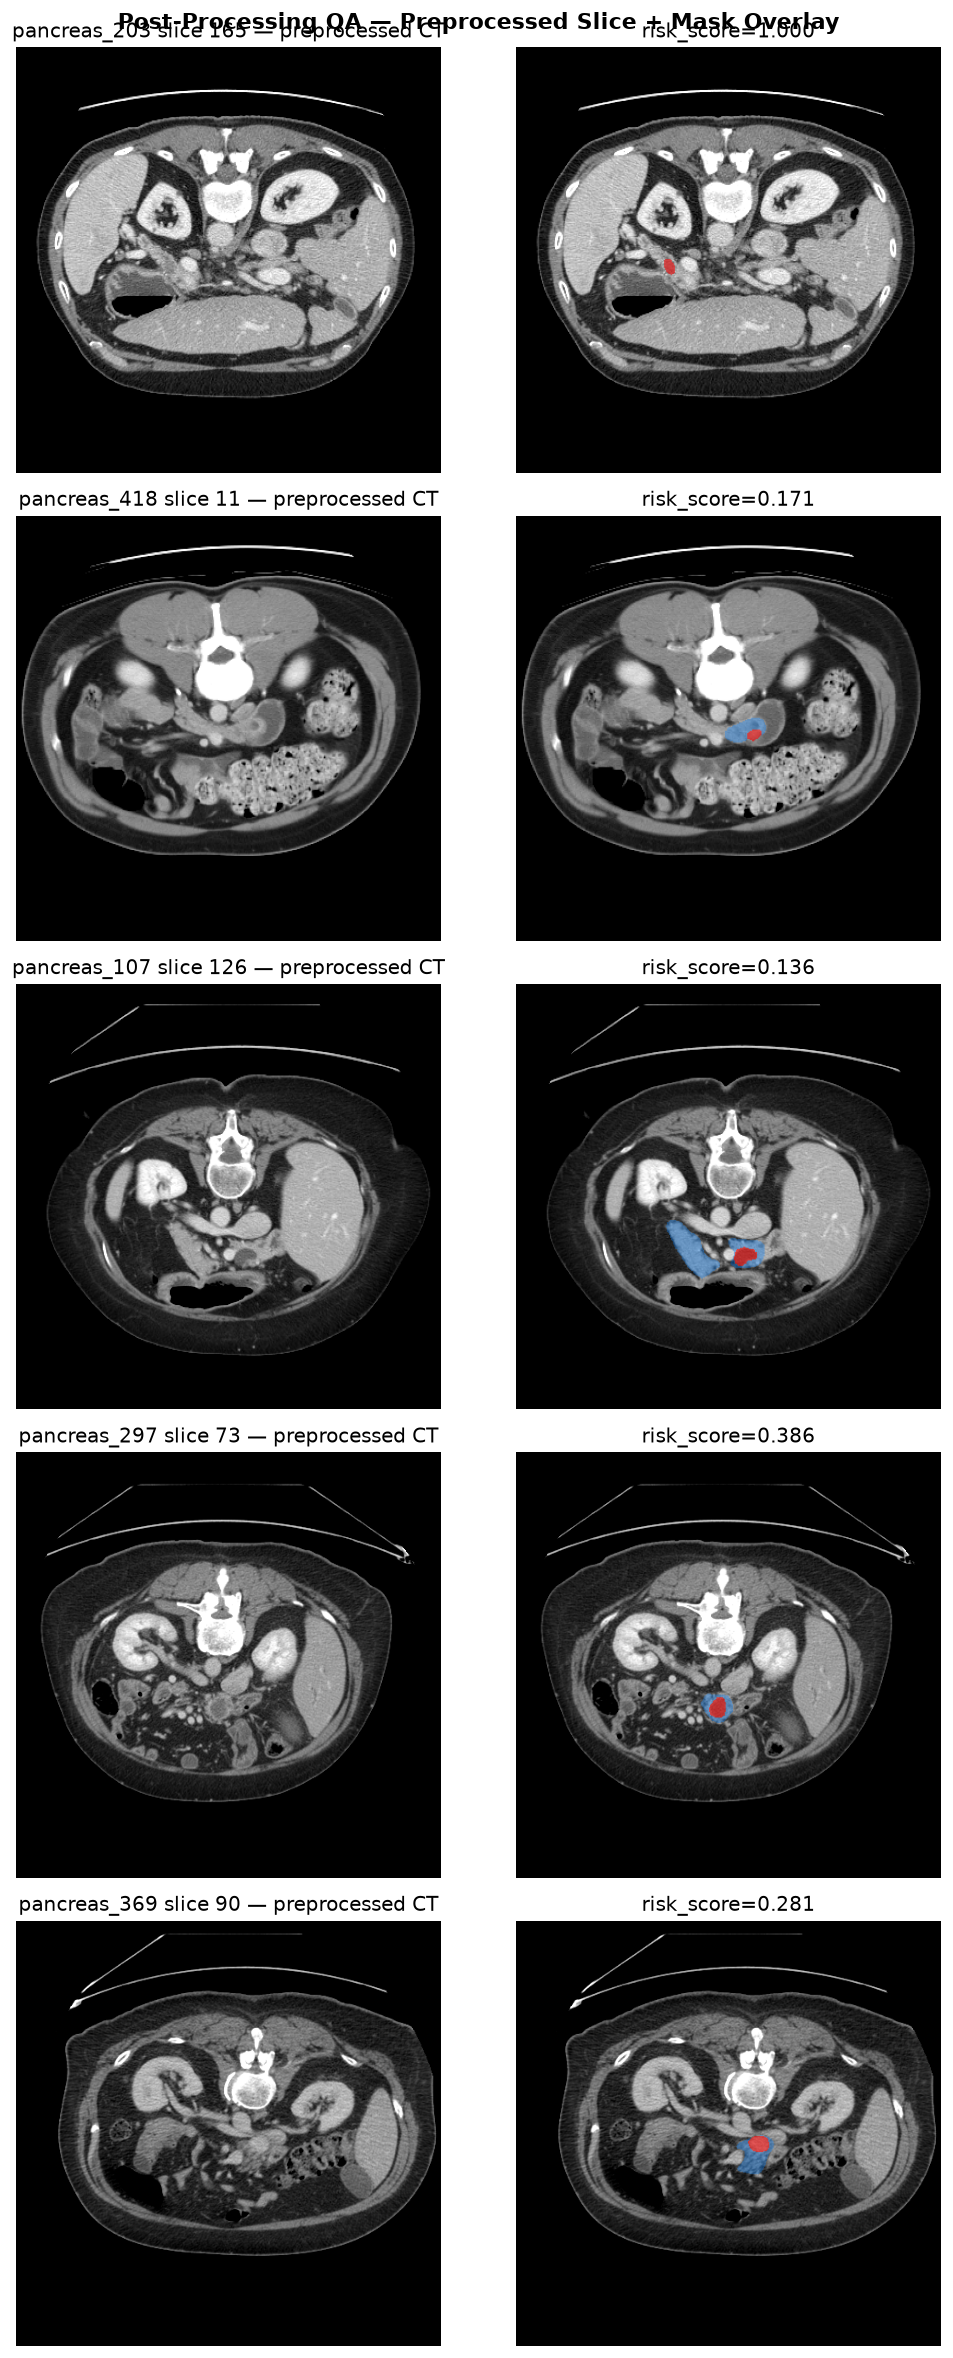

Saved: qa_preprocessed_overlay.png


In [10]:
random.seed(3)
qa_patients = random.sample(valid_patients, min(N_QA_SAMPLES, len(valid_patients)))

fig, axes = plt.subplots(len(qa_patients), 2, figsize=(9, 4 * len(qa_patients)))
if len(qa_patients) == 1:
    axes = axes.reshape(1, -1)
fig.suptitle('Post-Processing QA — Preprocessed Slice + Mask Overlay',
             fontsize=13, fontweight='bold')

for row, pid in enumerate(qa_patients):
    patient_rows = manifest_df[manifest_df.patient_id == pid]
    tumour_rows = patient_rows[patient_rows.risk_score > 0]
    chosen = tumour_rows.iloc[len(tumour_rows) // 2] if len(tumour_rows) > 0 \
        else patient_rows.iloc[len(patient_rows) // 2]

    img = np.load(os.path.join(OUTPUT_DIR, chosen.image_path))
    mask = np.load(os.path.join(OUTPUT_DIR, chosen.mask_path))

    axes[row, 0].imshow(img, cmap='gray')
    axes[row, 0].set_title(f'{pid} slice {chosen.slice_index} — preprocessed CT')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img, cmap='gray')
    overlay = np.zeros((*mask.shape, 4))
    overlay[mask == 1] = [0, 0.5, 1, 0.35]
    overlay[mask == 2] = [1, 0, 0, 0.55]
    axes[row, 1].imshow(overlay)
    axes[row, 1].set_title(f'risk_score={chosen.risk_score:.3f}')
    axes[row, 1].axis('off')

plt.tight_layout()
Path(QA_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(os.path.join(QA_OUTPUT_DIR, 'qa_preprocessed_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: qa_preprocessed_overlay.png")

## Final Summary

In [11]:
print("=" * 55)
print("  PREPROCESSING PIPELINE SUMMARY")
print("=" * 55)
print(f"\nExcluded at integrity gate: {len(excluded)}")
for pid, reason in excluded:
    print(f"  - {pid}: {reason}")
print(f"\nFailed during processing:  {len(processing_failures)}")
for pid, err in processing_failures:
    print(f"  - {pid}: {err}")

print(f"\nFinal patient counts:")
for split, pids in split_assignment.items():
    n_slices = int((manifest_df.split == split).sum())
    print(f"  {split}: {len(pids)} patients, {n_slices:,} slices")

print(f"\nTotal slices: {len(manifest_df):,}")
print(f"Total output size: {output_size_gb:.2f} GB (budget: {budget_gb:.0f} GB)")

  PREPROCESSING PIPELINE SUMMARY

Excluded at integrity gate: 0

Failed during processing:  0

Final patient counts:
  train: 196 patients, 50,337 slices
  val: 42 patients, 10,586 slices
  test: 43 patients, 11,154 slices

Total slices: 72,077
Total output size: 25.35 GB (budget: 50 GB)


## NIH Dataset Addendum: Healthy-Negative Cohort (Image-Only)

**Why:** the MSD cohort above is 100% cancer patients (`docs/CT_EDA_documentation.md` Section D) — the detection head has no true healthy-negative examples to learn a presence/absence distinction from. NIH Pancreas-CT (TCIA CT-82, 80 healthy subjects) fills that gap. Everything below is additive: the 281-patient MSD section above is untouched and none of its saved `.npy` files are re-processed or moved.

**Format correction vs. an earlier plan:** the NIH data on disk (`data/raw/NIH_Pancreas_CT/0024_pancreas_ct/images/*.nii.gz`, 80 files) is pre-converted single-file NIfTI, not a raw DICOM series — confirmed both by directory listing and by `docs/CT_EDA_documentation.md` Section L's provenance note (this copy came via a Hugging Face mirror of the original TCIA collection). There is no DICOM series to read here, so no `SimpleITK.ImageSeriesReader`/`GetGDCMSeriesFileNames` branch is needed — the existing `load_ct()` nibabel loader (above) already works on these files unchanged, exactly as the EDA addendum used it.

**Image-only, by design, not by convenience:** the `segmentations/` folders shipped alongside these images are multi-organ auto-segmentation output with no label-to-organ key available anywhere in the repo (same EDA finding). Guessing which numeric ID means "pancreas" risks silently mislabeling a different organ across all 80 patients. Nothing below loads, pairs, resamples, or references a mask for any NIH patient — the detection head only needs a patient-level healthy/cancer label, which doesn't require a mask at all.

**HU window — a documented decision, not a passed check:** the plan called for confirming the [-150, +250] HU window against NIH tissue before proceeding. A body-masked check (excludes voxels below -500 HU to remove background air) was run against all 80 NIH volumes and did **not** confirm the window (0.5th/99.5th percentile -457.0 / 612.0 HU vs. the window's ±50 HU tolerance around [-150, 250]). This was reviewed and the decision was made to proceed with the existing window anyway: a "body minus air" mask still includes bone, muscle, fat, and every other organ in the cross-section, not the pancreas specifically, so it was never a fair proxy for a window derived from clinical pancreas/tumour HU reference ranges — properly resolving this would need an actual NIH pancreas mask, which doesn't exist in this data copy. That reasoning and the numbers are reproduced in the validation cell below rather than hidden.

### NIH Configuration

New constants only — nothing above is changed. `SPLIT_MODE` defaults to k-fold (k=5) rather than the single 70/15/15 holdout used for MSD: with only ~80 healthy patients, a single random holdout risks putting too few (or an unrepresentative slice) of them in the test set, whereas 5-fold CV guarantees every healthy patient is evaluated as held-out test data in exactly one fold, which is what "honest CI reporting" for a small negative cohort actually needs.

In [12]:
# --- NIH (healthy-negative) paths -- pre-converted NIfTI, confirmed above ---
NIH_DATA_DIR = r"C:\FYP\data\raw\NIH_Pancreas_CT\0024_pancreas_ct\\"
NIH_IMG_DIR  = NIH_DATA_DIR + "images\\"

# --- Class / dataset labels (new manifest columns) ---
CLASS_HEALTHY, CLASS_CANCER = 0, 1
DATASET_NIH, DATASET_MSD = "NIH", "MSD"
NIH_RISK_SCORE_FIXED = 0.0   # no tumour possible in a healthy patient -- fixed, never computed

# --- HU-window validation gate (body-masked check, see markdown above) ---
BODY_HU_FLOOR = -500   # crude body mask: excludes background air, NOT organ-specific
HU_TOLERANCE = 50      # same tolerance the EDA used for its own window checks

# --- Merged split: configurable, defaults to k-fold (small negative cohort) ---
SPLIT_MODE = "kfold"      # "kfold" (default) or "holdout"
N_SPLITS_KFOLD = 5

print(f"NIH image dir: {NIH_IMG_DIR}")
print(f"Split mode: {SPLIT_MODE}" + (f" (k={N_SPLITS_KFOLD})" if SPLIT_MODE == "kfold" else ""))

NIH image dir: C:\FYP\data\raw\NIH_Pancreas_CT\0024_pancreas_ct\\images\
Split mode: kfold (k=5)


### NIH Helper

Reused verbatim from `notebooks/CT EDA.ipynb` Section L1. NIH's filenames are UID-based (`'00001_1.2.826...⁠_0000.nii.gz'`) — the existing `patient_id_from_filename` just strips the extension, which would keep the whole unreadable UID, so NIH needs its own short-ID extractor.

In [13]:
def nih_patient_id_from_filename(fname: str) -> str:
    """Extract the short case number from an NIH filename, e.g.
    '00001_1.2.826...⁠_0000.nii.gz' -> '00001'. NIH's own UID-based naming
    is unique but unreadable; MSD's patient_id_from_filename doesn't apply
    since it just strips the extension, which would keep the whole UID."""
    return fname.split('_')[0]


print("NIH helper reused: nih_patient_id_from_filename")

NIH helper reused: nih_patient_id_from_filename


### NIH-Specific Step Functions

Four new functions: the HU-window check (formalized here as a real function, not left as a one-off script, so the decision above has a reproducible audit trail in the pipeline itself), a stratification-key builder, and a holdout/k-fold pair of merged-split functions mirroring `stratified_patient_split` above but generalized to a precomputed strata array instead of deriving strata purely from lesion volume (NIH patients have no lesion to derive a quartile from).

In [14]:
def nih_hu_window_check(
    img_files: list[str], img_dir: str,
    hu_min: float, hu_max: float, body_hu_floor: float, tolerance: float, stride: int = 50,
) -> tuple[float, float, bool, list[str]]:
    """0.5th/99.5th HU percentile check for NIH, excluding voxels below
    body_hu_floor (a crude body mask -- removes background air, NOT organ-
    specific). Returns (p_low, p_high, window_ok, failed_filenames).
    """
    values = []
    failed = []
    for fname in img_files:
        try:
            ct, _ = load_ct(fname, img_dir)
        except CTLoadError as e:
            failed.append(e.fname)
            continue
        flat = ct.flatten()[::stride]
        values.extend(flat[flat >= body_hu_floor].tolist())
    values = np.array(values)
    p_low, p_high = np.percentile(values, [0.5, 99.5])
    window_ok = abs(p_low - hu_min) <= tolerance and abs(p_high - hu_max) <= tolerance
    return p_low, p_high, window_ok, failed


def build_merged_strata(
    patient_ids: list[str],
    patient_class: dict[str, int],
    lesion_volume_mm3: dict[str, float],
    n_cancer_strata: int,
) -> list[str]:
    """One stratification key per patient for the merged MSD+NIH split.
    Healthy (class=0) patients share a single 'healthy' stratum -- their
    lesion_volume_mm3 is a fixed 0.0 for all of them, which would collapse
    to one degenerate qcut bucket anyway, and lesion size isn't a meaningful
    concept for a cohort with no lesion. Cancer (class=1) patients keep the
    original lesion-size-quartile stratification, computed only over the
    cancer subset so NIH's fixed 0.0 volumes can't shift the MSD quartile
    boundaries.
    """
    cancer_ids = [pid for pid in patient_ids if patient_class[pid] == CLASS_CANCER]
    cancer_volumes = [lesion_volume_mm3[pid] for pid in cancer_ids]
    cancer_quartile = dict(zip(
        cancer_ids,
        pd.qcut(cancer_volumes, q=n_cancer_strata, labels=False, duplicates="drop"),
    ))
    return [
        f"cancer_q{cancer_quartile[pid]}" if patient_class[pid] == CLASS_CANCER else "healthy"
        for pid in patient_ids
    ]


def merged_holdout_split(
    patient_ids: list[str], strata: list[str],
    train_frac: float, val_frac: float, test_frac: float, seed: int,
) -> dict[str, str]:
    """Single 70/15/15 holdout over the merged cohort, stratified by the
    combined class/lesion-quartile key so every split gets both classes.
    """
    train_ids, rest_ids, _, rest_strata = train_test_split(
        patient_ids, strata, train_size=train_frac, stratify=strata, random_state=seed
    )
    val_ratio_of_rest = val_frac / (val_frac + test_frac)
    val_ids, test_ids = train_test_split(
        rest_ids, train_size=val_ratio_of_rest, stratify=rest_strata, random_state=seed
    )
    return {
        **{p: "train" for p in train_ids},
        **{p: "val" for p in val_ids},
        **{p: "test" for p in test_ids},
    }


def merged_kfold_split(
    patient_ids: list[str], strata: list[str], n_splits: int, seed: int
) -> dict[str, str]:
    """Stratified k-fold over the merged cohort. Each patient is assigned to
    exactly one fold label (e.g. 'fold2') -- the fold a patient is tagged
    with is the one where it's held out as test data; every other fold is
    pooled as training for that run. StratifiedKFold on the combined class/
    lesion-quartile key guarantees both healthy and cancer patients land in
    every fold.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    patient_to_fold = {}
    for fold_idx, (_, test_pos) in enumerate(skf.split(patient_ids, strata)):
        for pos in test_pos:
            patient_to_fold[patient_ids[pos]] = f"fold{fold_idx}"
    return patient_to_fold


print("NIH pipeline step functions defined: nih_hu_window_check, build_merged_strata, "
      "merged_holdout_split, merged_kfold_split")

NIH pipeline step functions defined: nih_hu_window_check, build_merged_strata, merged_holdout_split, merged_kfold_split


### NIH Integrity Gate (Image-Only)

Mirrors Step 1's pattern above with everything mask-related removed: the only check possible is whether the image itself loads. No shape-match, no orientation-vs-mask, no label validation — there's no mask to check any of that against. `lesion_volume_mm3`, `class`, and `dataset` are recorded per patient as fixed values (0.0 / healthy / NIH), not computed from anything, since there's no lesion and no mask to derive them from. The MSD `class`/`dataset` bookkeeping is added here too — pure bookkeeping over the already-validated `valid_patients` list from Step 1, no reprocessing.

In [15]:
nih_img_files = sorted([
    f for f in os.listdir(NIH_IMG_DIR)
    if f.endswith('.nii.gz') and not f.startswith('._')
])

print(f"Running image-only integrity gate on {len(nih_img_files)} NIH candidate patients...")

nih_excluded = []        # (patient_id, reason) -- load failures only, no mask checks possible
valid_nih_patients = []  # patient_ids that passed
nih_pid_to_fname = {}    # patient_id -> original filename (needed later, UID-based names)

for fname in nih_img_files:
    pid = nih_patient_id_from_filename(fname)
    try:
        ct, ct_nib = load_ct(fname, NIH_IMG_DIR)
    except CTLoadError as e:
        nih_excluded.append((pid, f"load_error: {e}"))
        continue
    valid_nih_patients.append(pid)
    nih_pid_to_fname[pid] = fname

# Fixed assignments -- never computed from a mask, since none is used for NIH
for pid in valid_nih_patients:
    lesion_volume_mm3[pid] = 0.0

# Class/dataset bookkeeping for both cohorts (MSD side is pure bookkeeping over
# the already-validated Step 1 list -- no reprocessing)
patient_class = {pid: CLASS_CANCER for pid in valid_patients}
patient_dataset = {pid: DATASET_MSD for pid in valid_patients}
for pid in valid_nih_patients:
    patient_class[pid] = CLASS_HEALTHY
    patient_dataset[pid] = DATASET_NIH

print("\n" + "=" * 55)
print("  NIH INTEGRITY GATE RESULT (IMAGE-ONLY)")
print("=" * 55)
print(f"  Candidates checked: {len(nih_img_files)}")
print(f"  Passed:             {len(valid_nih_patients)}")
print(f"  Excluded:            {len(nih_excluded)}")
for pid, reason in nih_excluded:
    print(f"    - {pid}: {reason}")

Running image-only integrity gate on 80 NIH candidate patients...



  NIH INTEGRITY GATE RESULT (IMAGE-ONLY)
  Candidates checked: 80
  Passed:             80
  Excluded:            0


### NIH HU Window Validation

Reruns the body-masked check inside the pipeline itself (not just as a throwaway script) so the numbers and the decision are reproducible from this notebook alone. Prints the honest result either way — if it fails tolerance, that's stated plainly, followed by the reviewed rationale for proceeding anyway rather than silently treating an unconfirmed check as a pass.

In [16]:
nih_p_low, nih_p_high, nih_window_confirmed, nih_hu_failed = nih_hu_window_check(
    nih_img_files, NIH_IMG_DIR, HU_MIN, HU_MAX, BODY_HU_FLOOR, HU_TOLERANCE
)

print("-" * 55)
print(f"  NIH HU WINDOW CHECK (body-masked, floor={BODY_HU_FLOOR} HU, stride=50)")
print("-" * 55)
print(f"  0.5th percentile HU:  {nih_p_low:.1f}")
print(f"  99.5th percentile HU: {nih_p_high:.1f}")
print(f"  MSD-derived window:   [{HU_MIN}, {HU_MAX}], tolerance +/-{HU_TOLERANCE}")
if nih_hu_failed:
    print(f"  {len(nih_hu_failed)} patients failed to load during this check: {nih_hu_failed}")

if nih_window_confirmed:
    print("\n  CONFIRMED: window holds within tolerance.")
else:
    print("\n  NOT CONFIRMED -- window differs by more than tolerance on at least one side.")
    print("  DECISION (reviewed explicitly, not silently overridden): proceeding with the existing")
    print("  [-150, +250] window anyway. A 'body minus air' mask still includes bone, muscle, fat,")
    print("  and every other organ in the cross-section, not the pancreas specifically -- the window")
    print("  was derived from clinical HU reference ranges for pancreas/tumour tissue (25-55 / 10-40")
    print("  HU), which a whole-body percentile was never going to confirm without an actual pancreas")
    print("  mask. NIH has no usable one in this data copy (docs/CT_EDA_documentation.md Section L).")
    print("  Revisit if a genuine NIH pancreas mask becomes available.")

-------------------------------------------------------
  NIH HU WINDOW CHECK (body-masked, floor=-500 HU, stride=50)
-------------------------------------------------------
  0.5th percentile HU:  -457.0
  99.5th percentile HU: 612.0
  MSD-derived window:   [-150, 250], tolerance +/-50

  NOT CONFIRMED -- window differs by more than tolerance on at least one side.
  DECISION (reviewed explicitly, not silently overridden): proceeding with the existing
  [-150, +250] window anyway. A 'body minus air' mask still includes bone, muscle, fat,
  and every other organ in the cross-section, not the pancreas specifically -- the window
  was derived from clinical HU reference ranges for pancreas/tumour tissue (25-55 / 10-40
  HU), which a whole-body percentile was never going to confirm without an actual pancreas
  mask. NIH has no usable one in this data copy (docs/CT_EDA_documentation.md Section L).
  Revisit if a genuine NIH pancreas mask becomes available.


### Merged Patient Split (MSD + NIH)

Re-derives the split over all ~361 patients jointly, stratified by class (and, within the cancer class only, by lesion-size quartile as before) so every fold/split contains both cancer and healthy patients. This **supersedes Step 9 above for the final manifest** — Step 9's `split_assignment`/`patient_to_split` remain a true record of the split used when the currently-saved MSD `.npy` files were written, but since those files are never moved or renamed, a patient's physical folder (`images/train/...` etc.) no longer necessarily matches its current logical split. Only the manifest's `split` column is re-derived here; that's the one thing point 4 of the plan says must change.

In [17]:
merged_patient_ids = valid_patients + valid_nih_patients
merged_strata = build_merged_strata(merged_patient_ids, patient_class, lesion_volume_mm3, N_LESION_STRATA)

if SPLIT_MODE == "kfold":
    merged_patient_to_split = merged_kfold_split(merged_patient_ids, merged_strata, N_SPLITS_KFOLD, RANDOM_SEED)
elif SPLIT_MODE == "holdout":
    merged_patient_to_split = merged_holdout_split(
        merged_patient_ids, merged_strata, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, RANDOM_SEED
    )
else:
    raise ValueError(f"Unknown SPLIT_MODE: {SPLIT_MODE!r}")

print(f"Merged split mode: {SPLIT_MODE}")
print(f"Merged patient count: {len(merged_patient_ids)} "
      f"({len(valid_patients)} MSD + {len(valid_nih_patients)} NIH)")
print()

merged_split_preview_df = pd.DataFrame([
    {
        "patient_id": pid,
        "dataset": patient_dataset[pid],
        "class": patient_class[pid],
        "split": merged_patient_to_split[pid],
    }
    for pid in merged_patient_ids
])

print("Patients per split/fold, per dataset:")
print(merged_split_preview_df.groupby(["split", "dataset"]).size().unstack(fill_value=0))

Merged split mode: kfold
Merged patient count: 361 (281 MSD + 80 NIH)

Patients per split/fold, per dataset:
dataset  MSD  NIH
split            
fold0     57   16
fold1     56   16
fold2     56   16
fold3     56   16
fold4     56   16


### NIH Processing Loop (Image-Only)

Image-only mirror of the main MSD loop above: reorient → resample → clip → normalise → extract slices → save uint8. No mask is loaded, resampled, or saved anywhere in this loop — there's no `mask_img`/`MASK_INTERPOLATOR`/`mask_to_uint8` call at all, not even against a placeholder. `risk_score` is the fixed `NIH_RISK_SCORE_FIXED` (0.0) for every slice, not computed from anything.

Saved under `images/nih/` — a dataset-only folder, not a split-named one. Since a patient's split/fold assignment can now be re-derived (Merged Split above) without moving files, encoding the split into the folder name would only create a mismatch the next time the split changes; the manifest's `split` column is the single source of truth for split membership, same principle noted above for why MSD's files don't move when its split label changes.

In [18]:
Path(OUTPUT_DIR, 'images', 'nih').mkdir(parents=True, exist_ok=True)

nih_manifest_rows = []
nih_processing_failures = []  # (patient_id, error message)

start_time = time.time()
for n, pid in enumerate(valid_nih_patients, 1):
    fname = nih_pid_to_fname[pid]
    split = merged_patient_to_split[pid]
    try:
        ct_img = sitk.ReadImage(NIH_IMG_DIR + fname)
        ct_img = reorient_to_ras(ct_img)
        ct_img = resample_to_spacing(ct_img, TARGET_SPACING, IMAGE_INTERPOLATOR, default_value=-1024)

        ct_arr = sitk.GetArrayFromImage(ct_img)  # (z, y, x)
        ct_arr = clip_hu(ct_arr, HU_MIN, HU_MAX)
        ct_arr = normalize_to_unit_range(ct_arr, HU_MIN, HU_MAX)

        ct_slices = extract_axial_slices(ct_arr)
        # No mask loading, no mask resampling, no mask_to_uint8 call -- image-only.

        for slice_idx, ct_slice in enumerate(ct_slices):
            img_u8 = slice_to_uint8_image(ct_slice)

            img_fname = f"nih_{pid}_slice{slice_idx:04d}.npy"
            img_path = os.path.join('images', 'nih', img_fname)
            np.save(os.path.join(OUTPUT_DIR, img_path), img_u8)

            nih_manifest_rows.append({
                'patient_id': f"nih_{pid}",
                'slice_index': slice_idx,
                'split': split,
                'risk_score': NIH_RISK_SCORE_FIXED,  # fixed, not computed -- no mask exists
                'image_path': img_path.replace(os.sep, '/'),
                'mask_path': None,                    # no mask for NIH, ever
                'class': CLASS_HEALTHY,
                'dataset': DATASET_NIH,
            })

    except Exception as e:
        nih_processing_failures.append((pid, str(e)))
        continue

    if n % 20 == 0 or n == len(valid_nih_patients):
        elapsed = time.time() - start_time
        print(f"  Processed {n}/{len(valid_nih_patients)} NIH patients "
              f"({elapsed/60:.1f} min elapsed)")

print(f"\nNIH processing complete. {len(nih_processing_failures)} patients failed during "
      f"reorient/resample/save.")
for pid, err in nih_processing_failures:
    print(f"  - {pid}: {err}")

  Processed 20/80 NIH patients (0.4 min elapsed)


  Processed 40/80 NIH patients (0.8 min elapsed)


  Processed 60/80 NIH patients (1.2 min elapsed)


  Processed 80/80 NIH patients (1.6 min elapsed)

NIH processing complete. 0 patients failed during reorient/resample/save.


### Manifest Merge

Backs up the existing MSD-only manifest first (reversible), adds `class`/`dataset` columns to its rows, overwrites their `split` value via the merged split assignment, concatenates with the new NIH rows, and saves. No MSD `image_path`/`mask_path` values change — only `split`, plus the two new columns.

In [19]:
manifest_backup_path = os.path.join(OUTPUT_DIR, 'manifest_msd_only_backup.csv')
shutil.copy(manifest_path, manifest_backup_path)
print(f"Backed up original MSD-only manifest to: {manifest_backup_path}")

msd_manifest_df = pd.read_csv(manifest_path)
msd_manifest_df['class'] = CLASS_CANCER
msd_manifest_df['dataset'] = DATASET_MSD
msd_manifest_df['split'] = msd_manifest_df['patient_id'].map(merged_patient_to_split)

assert msd_manifest_df['split'].isna().sum() == 0, "some MSD patients missing from the merged split"

nih_manifest_df = pd.DataFrame(nih_manifest_rows)

merged_manifest_df = pd.concat([msd_manifest_df, nih_manifest_df], ignore_index=True)
merged_manifest_df.to_csv(manifest_path, index=False)

print(f"Merged manifest saved: {manifest_path}")
print(f"Total rows: {len(merged_manifest_df):,} "
      f"({len(msd_manifest_df):,} MSD + {len(nih_manifest_df):,} NIH)")
print()
print("Slices per split/fold, per dataset:")
print(merged_manifest_df.groupby(['dataset', 'split']).size().unstack(fill_value=0))

Backed up original MSD-only manifest to: C:\FYP\data\processed\manifest_msd_only_backup.csv


Merged manifest saved: C:\FYP\data\processed\manifest.csv
Total rows: 90,693 (72,077 MSD + 18,616 NIH)

Slices per split/fold, per dataset:
split    fold0  fold1  fold2  fold3  fold4
dataset                                   
MSD      14428  15062  13995  13880  14712
NIH       4126   3701   3744   3518   3527


### NIH Fixed-Value Confirmation

Explicit assertion, not just a claim in prose: every NIH row in the final merged manifest has `risk_score == 0.0` and a null `mask_path`.

In [20]:
nih_rows = merged_manifest_df[merged_manifest_df.dataset == DATASET_NIH]

assert (nih_rows['risk_score'] == 0.0).all(), "found a non-zero NIH risk score -- should never happen"
assert nih_rows['mask_path'].isna().all(), "found a non-null NIH mask_path -- should never happen"

print(f"Confirmed: all {len(nih_rows):,} NIH manifest rows have risk_score == 0.0 (fixed) "
      f"and mask_path == null.")

Confirmed: all 18,616 NIH manifest rows have risk_score == 0.0 (fixed) and mask_path == null.


### NIH Visual QA (Image-Only)

No mask exists to overlay, so this is a simpler sanity check than Step 11 above: load the saved uint8 slice back from disk (round-trip, not an in-memory re-plot) for a handful of random NIH patients and look at it directly — correct orientation, plausible abdominal anatomy, no obvious DICOM-assembly/resampling artifacts.

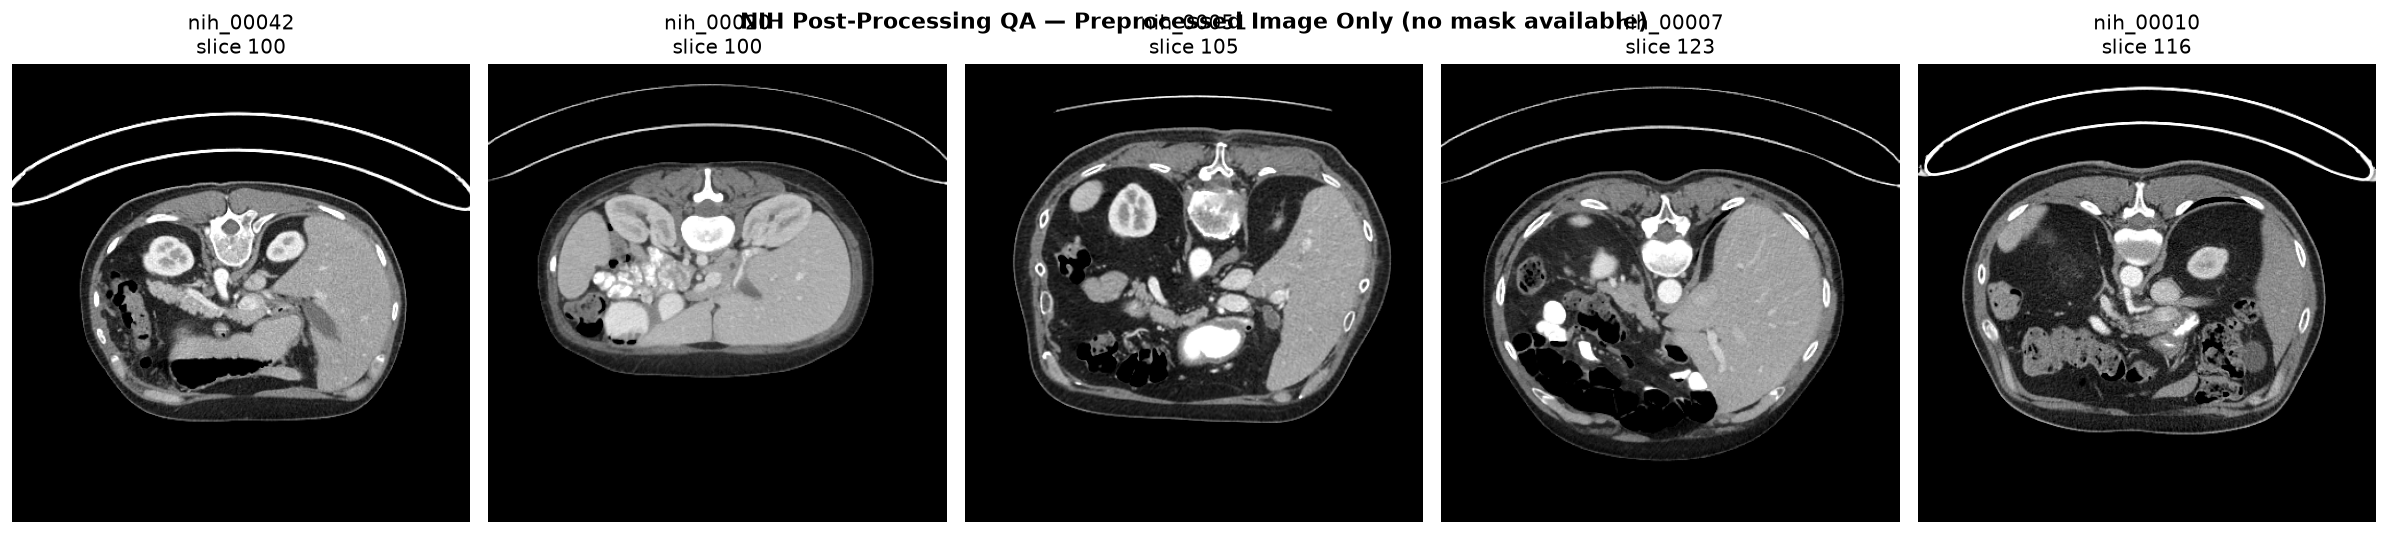

Saved: qa_nih_preprocessed.png


In [21]:
random.seed(7)
nih_qa_patients = random.sample(valid_nih_patients, min(N_QA_SAMPLES, len(valid_nih_patients)))

fig, axes = plt.subplots(1, len(nih_qa_patients), figsize=(4 * len(nih_qa_patients), 4.5))
if len(nih_qa_patients) == 1:
    axes = [axes]
fig.suptitle('NIH Post-Processing QA — Preprocessed Image Only (no mask available)',
             fontsize=13, fontweight='bold')

for col, pid in enumerate(nih_qa_patients):
    patient_rows = nih_manifest_df[nih_manifest_df.patient_id == f"nih_{pid}"]
    chosen = patient_rows.iloc[len(patient_rows) // 2]

    img = np.load(os.path.join(OUTPUT_DIR, chosen.image_path))

    axes[col].imshow(img, cmap='gray')
    axes[col].set_title(f'nih_{pid}\nslice {chosen.slice_index}')
    axes[col].axis('off')

plt.tight_layout()
Path(QA_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
plt.savefig(os.path.join(QA_OUTPUT_DIR, 'qa_nih_preprocessed.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: qa_nih_preprocessed.png")

### Disk Usage Recheck (MSD + NIH)

Reuses `get_dir_size_bytes` from the MSD section unchanged — actual measured size, not an estimate, now covering the NIH images too.

In [22]:
output_size_bytes = get_dir_size_bytes(OUTPUT_DIR)
output_size_gb = output_size_bytes / 1e9

print(f"Total output size (MSD + NIH): {output_size_gb:.2f} GB")
print(f"Budget:                        {budget_gb:.0f} GB")
if output_size_gb <= budget_gb:
    print(f"WITHIN BUDGET -- {budget_gb - output_size_gb:.2f} GB to spare")
else:
    print(f"OVER BUDGET by {output_size_gb - budget_gb:.2f} GB")

free_space_gb = shutil.disk_usage(OUTPUT_DIR).free / 1e9
print(f"Actual free disk space remaining on this drive: {free_space_gb:.2f} GB")

Total output size (MSD + NIH): 28.89 GB
Budget:                        50 GB
WITHIN BUDGET -- 21.11 GB to spare
Actual free disk space remaining on this drive: 320.28 GB


### NIH Addendum Summary

In [23]:
print("=" * 55)
print("  NIH ADDENDUM SUMMARY")
print("=" * 55)

print(f"\nNIH integrity gate: {len(nih_img_files)} checked, {len(valid_nih_patients)} passed, "
      f"{len(nih_excluded)} excluded")
for pid, reason in nih_excluded:
    print(f"  - {pid}: {reason}")

print(f"\nNIH processing failures: {len(nih_processing_failures)}")
for pid, err in nih_processing_failures:
    print(f"  - {pid}: {err}")

print(f"\nHU window check (body-masked): "
      f"{'CONFIRMED' if nih_window_confirmed else 'NOT CONFIRMED -- proceeded per documented decision above'}")

print(f"\nMerged patient counts per {'fold' if SPLIT_MODE == 'kfold' else 'split'} per class:")
print(merged_manifest_df.drop_duplicates('patient_id').groupby(['split', 'dataset']).size().unstack(fill_value=0))

print(f"\nNIH risk scores: confirmed fixed at 0.0 for all {len(nih_rows):,} NIH rows, "
      f"mask_path null for all of them")

print(f"\nTotal manifest rows: {len(merged_manifest_df):,} "
      f"({len(msd_manifest_df):,} MSD + {len(nih_manifest_df):,} NIH)")
print(f"Total output size: {output_size_gb:.2f} GB (budget: {budget_gb:.0f} GB)")

  NIH ADDENDUM SUMMARY

NIH integrity gate: 80 checked, 80 passed, 0 excluded

NIH processing failures: 0

HU window check (body-masked): NOT CONFIRMED -- proceeded per documented decision above

Merged patient counts per fold per class:
dataset  MSD  NIH
split            
fold0     57   16
fold1     56   16
fold2     56   16
fold3     56   16
fold4     56   16

NIH risk scores: confirmed fixed at 0.0 for all 18,616 NIH rows, mask_path null for all of them

Total manifest rows: 90,693 (72,077 MSD + 18,616 NIH)
Total output size: 28.89 GB (budget: 50 GB)
